## Analyse en Composantes Principales (ACP)

**Données :** track.csv

**Etudiant :** Perrin Gaël Kibiti Pembe

**1. Chargement et exploration des données**

Nous importons les bibliothèques nécessaires, puis chargeons les données sur les records d’athlétisme (Track). L’exploration initiale permet de vérifier leur structure et la présence de la colonne pays.


In [14]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:/Users/gpkib/Gpkibiti Dropbox/Gael Kibiti/Université de Lille/Analyse de données I (6ECTS)/track.csv",sep=";")
df.head()

,100M,200M,400M,800M,1500M,5000M,10000M,MARATHON,PAYS
0,10.39,20.81,46.84,1.81,3.70,14.04,29.36,137.72,argentin
1,10.31,20.06,44.84,1.74,3.57,13.28,27.66,128.30,australi
2,10.44,20.81,46.82,1.79,3.60,13.26,27.72,135.90,austria
3,10.34,20.68,45.04,1.73,3.60,13.22,27.45,129.95,belgium
4,10.28,20.58,45.91,1.80,3.75,14.68,30.55,146.62,bermuda


**2. Dimensions et structure**

On vérifie la dimension, les colonnes, et les statistiques descriptives pour s’assurer que l’échantillon est cohérent.

In [15]:
print('Dimensions :', df.shape)
print('Colonnes :', df.columns)
print('Description :\n', df.describe())

Dimensions : (55, 9)
Colonnes : Index(['100M', '200M', '400M', '800M', '1500M', '5000M', '10000M', 'MARATHON',
       'PAYS'],
      dtype='object')
Description :
             100M       200M       400M       800M      1500M      5000M  \
count  55.000000  55.000000  55.000000  55.000000  55.000000  55.000000   
mean   10.471091  20.940364  46.438727   1.793273   3.698182  13.845818   
std     0.351429   0.644647   1.457018   0.063685   0.155909   0.801160   
min     9.930000  19.720000  43.860000   1.700000   3.510000  13.010000   
25%    10.270000  20.595000  45.560000   1.755000   3.600000  13.275000   
50%    10.410000  20.810000  46.100000   1.790000   3.640000  13.500000   
75%    10.590000  21.285000  47.300000   1.815000   3.770000  14.145000   
max    12.180000  23.200000  52.940000   2.020000   4.240000  16.700000   

          10000M    MARATHON  
count  55.000000   55.000000  
mean   28.989091  136.624000  
std     1.807732    9.227033  
min    27.380000  128.220000  
25%  

**Interprétation :** Ici, chaque ligne correspond à un pays, chaque colonne à une épreuve. Les écarts-types élevés montrent de vraies dispersions de performances.

**3. Préparation des données pour l’ACP**

On retire la colonne pays (non numérique) et on prépare la matrice de correlations pour l’ACP.


In [16]:
if 'PAYS' in df.columns:
    pays = df['PAYS']
    data = df.drop(columns=['PAYS'])
else:
    data = df
print(data)

     100M   200M   400M  800M  1500M  5000M  10000M  MARATHON
0   10.39  20.81  46.84  1.81   3.70  14.04   29.36    137.72
1   10.31  20.06  44.84  1.74   3.57  13.28   27.66    128.30
2   10.44  20.81  46.82  1.79   3.60  13.26   27.72    135.90
3   10.34  20.68  45.04  1.73   3.60  13.22   27.45    129.95
4   10.28  20.58  45.91  1.80   3.75  14.68   30.55    146.62
5   10.22  20.43  45.21  1.73   3.66  13.62   28.62    133.13
6   10.64  21.52  48.30  1.80   3.85  14.45   30.28    139.95
7   10.17  20.22  45.68  1.76   3.63  13.55   28.09    130.15
8   10.34  20.80  46.20  1.79   3.71  13.61   29.30    134.03
9   10.51  21.04  47.30  1.81   3.73  13.90   29.13    133.53
10  10.43  21.05  46.10  1.82   3.74  13.49   27.88    131.35
11  12.18  23.20  52.94  2.02   4.24  16.70   35.38    164.70
12  10.94  21.90  48.66  1.87   3.84  14.03   28.81    136.58
13  10.35  20.65  45.64  1.76   3.58  13.42   28.19    134.32
14  10.56  20.52  45.89  1.78   3.61  13.50   28.11    130.78
15  10.1

**Interprétation :** L’ACP nécessite uniquement des variables quantitatives. Les noms de pays serviront pour l’annotation des graphiques. Comme nous le remarquons, la colonne des pays a été supprimée afin de ne travailler qu'avec des données numériques. 

**4. Matrice de corrélation**

On visualise la corrélation entre les variables (épreuves sportives).

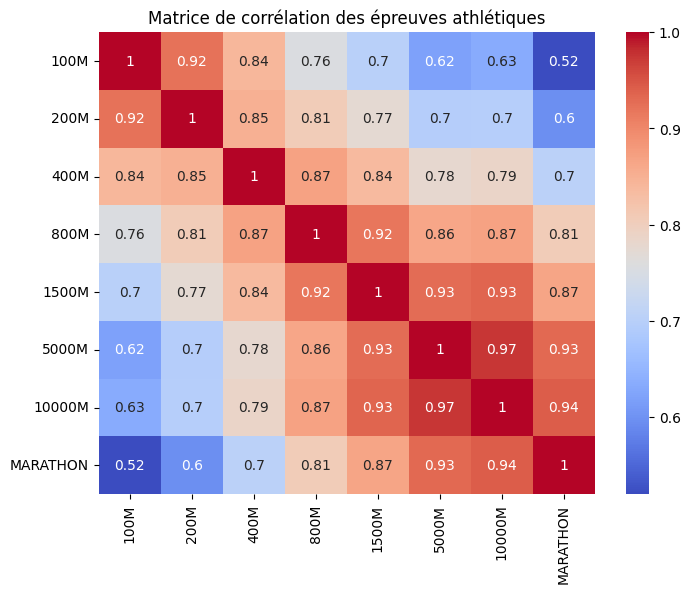

In [17]:
cor_matrix = data.corr()
plt.figure(figsize=(8,6))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation des épreuves athlétiques')
plt.show()



**Interprétation :** Les corrélations élevées, par exemple entre 10000M et Marathon (>0.90), indiquent que la performance dans une épreuve renseigne sur l’autre. Cela justifie l’usage de l’ACP, qui exploite ces redondances.

**5. Standardisation et Analyse en Composantes Principales (ACP)**

On standardise, c'est à dire contrer et réduire les données avant l’ACP. On projette ensuite les données.

Toutes les épreuves étant sur des échelles différentes, la standardisation évite que les courses longues ne dominent l’analyse.


In [18]:
scaler = StandardScaler()
X = scaler.fit_transform(data)
pca = PCA()
X_pca = pca.fit_transform(X)


**6. Éboulis des valeurs propres & variance expliquée**

On trace la représentation graphique de variance expliqué pour chaque composante.


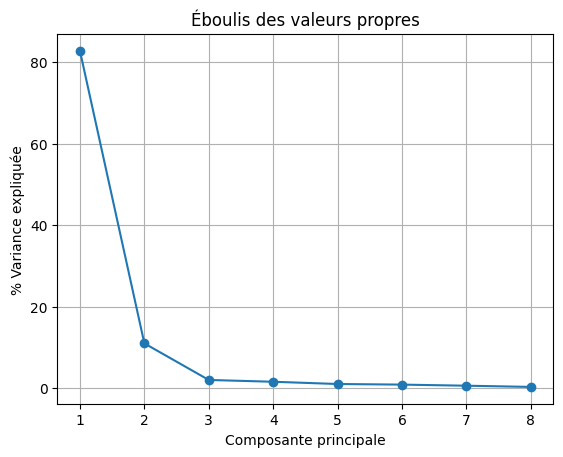

Valeurs propres : [6.74 0.89 0.16 0.13 0.08 0.07 0.05 0.02]
% variance par composante : [82.78 10.97  1.99  1.55  1.    0.85  0.58  0.28]
Variance cumulée : [ 82.78  93.75  95.74  97.29  98.29  99.14  99.72 100.  ]


In [19]:
plt.plot(np.arange(1, len(pca.explained_variance_)+1), pca.explained_variance_ratio_*100, marker='o')
plt.xlabel('Composante principale')
plt.ylabel('% Variance expliquée')
plt.title('Éboulis des valeurs propres')
plt.grid()
plt.show()
print('Valeurs propres :', np.round(pca.explained_variance_,2))
print('% variance par composante :', np.round(pca.explained_variance_ratio_*100, 2))
print('Variance cumulée :', np.round(np.cumsum(pca.explained_variance_ratio_)*100,2))

**Interprétation :** 

* La première composante explique à elle seule 82,78% de la variance totale.
* La deuxième composante ajoute 10,97%.

Ensemble, les deux axes résument 93,75% de l’information totale du jeu de données. Les autres composantes (3 à 8) expliquent chacune moins de 2% : elles apportent très peu d’informations nouvelles ou pertinentes.D'où le choix des deux premières composantes associées aux deux plus grandes valeurs propres. 

**7. Cercle des corrélations**

On projette les épreuves sur le plan factoriel.


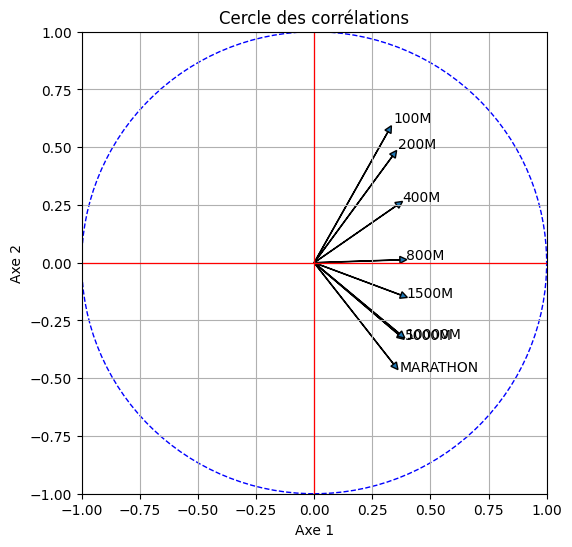

In [20]:
pcs = pd.DataFrame(pca.components_[:2].T, columns=['Axe1','Axe2'], index=data.columns)
fig, ax = plt.subplots(figsize=(6,6))
for i in range(len(pcs)):
    ax.arrow(0,0, pcs.iloc[i,0], pcs.iloc[i,1], head_width=0.03, head_length=0.03)
    ax.text(pcs.iloc[i,0]*1.07, pcs.iloc[i,1]*1.07, pcs.index[i])
circle = plt.Circle((0,0),1,facecolor='none',edgecolor='b',ls='--')
ax.add_artist(circle)
plt.xlim(-1,1); plt.ylim(-1,1)
plt.xlabel('Axe 1'); plt.ylabel('Axe 2')
plt.title('Cercle des corrélations')
ax.axhline(0, color='red', lw=0.9)
ax.axvline(0, color='red', lw=0.9)
plt.grid()
plt.show()


**Interprétation :** Les épreuves de MARATHON sont proches, très bien représentées sur le 1er axe (longueur de flèche proche de 1), ce qui confirme leur forte corrélation et poids dans la structure de données.

**8. Plan factoriel des individus**

On projette chaque pays dans le plan ACP.

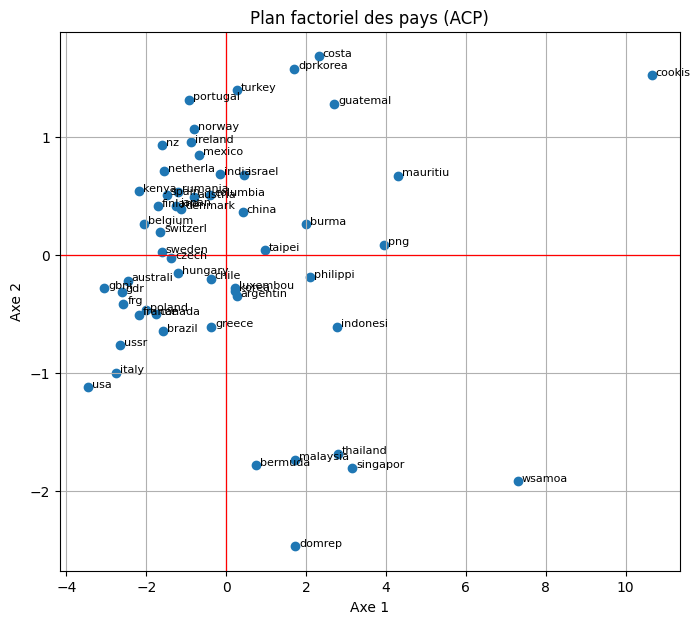

In [21]:
fig, ax = plt.subplots(figsize=(8,7))
ax.scatter(X_pca[:,0], X_pca[:,1])
if 'PAYS' in df.columns:
    for i, country in enumerate(pays):
        ax.text(X_pca[i,0]+0.1, X_pca[i,1], str(country), fontsize=8)
plt.xlabel('Axe 1')
plt.ylabel('Axe 2')
plt.title('Plan factoriel des pays (ACP)')
ax.axhline(0, color='red', lw=0.9)
ax.axvline(0, color='red', lw=0.9)
plt.grid()
plt.show()


**Interprétation :** Les pays les plus à gauche (axe 1 très négatif) sont ceux qui performent le mieux globalement (USA, France, Italie, Ussr…). Les petits pays situés en haut et à droite (Cookis, Costa, ...) peuvent être des cas atypiques.


**9. Biplot (variables et individus)**

On combine la visualisation des axes pays (individus) et des épreuves sportives (variables) pour voir les proximités et oppositions principales.

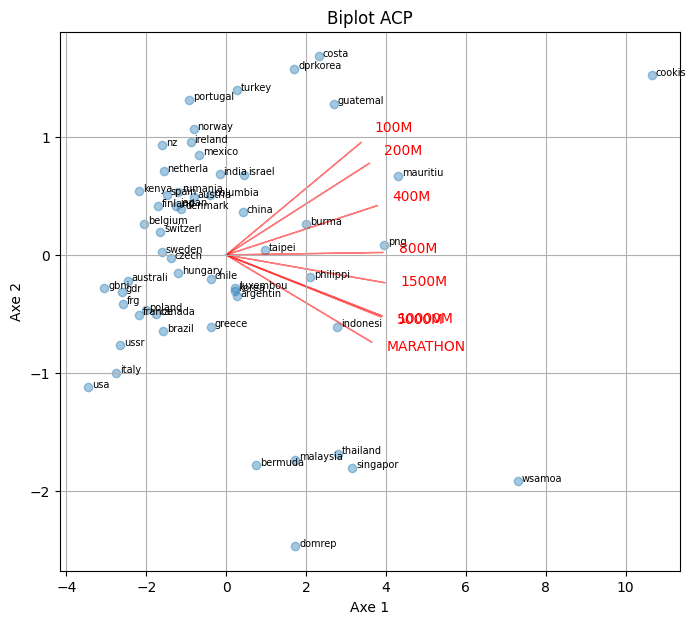

In [22]:
def biplot(score, coeff, labels=None):
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    plt.figure(figsize=(8,7))
    plt.scatter(xs, ys, alpha=0.4)
    if labels is not None:
        for i in range(len(xs)):
            plt.text(xs[i]+0.1, ys[i], labels[i], fontsize=7)
    for i in range(n):
        plt.arrow(0,0, coeff[i,0]*max(xs), coeff[i,1]*max(ys), color='r', alpha=0.5)
        plt.text(coeff[i,0]*max(xs)*1.1, coeff[i,1]*max(ys)*1.1, data.columns[i], color='r')
    plt.xlabel('Axe 1')
    plt.ylabel('Axe 2')
    plt.title('Biplot ACP')
    ax.axhline(0, color='red', lw=0.9)
    ax.axvline(0, color='red', lw=0.9)
    plt.grid()
biplot(X_pca, pca.components_.T, pays if 'PAYS' in df.columns else None)


**Interprétation :** On peut lire sur ce biplot quels pays sont associés à quelles épreuves, et voir immédiatement les nations « fortes partout » ou à profil particulier.

**10. Pays et profils atypiques**

On liste les pays les plus extrêmes sur les axes principaux afin de faire une interprétation complète.


In [23]:
projection = pd.DataFrame(X_pca[:,:2], columns=['Axe1','Axe2'], index=(pays if 'PAYS' in df.columns else df.index))
extr_mes = projection[(abs(projection.Axe1)>2)|(abs(projection.Axe2)>2)]
print('Pays atypiques ou extrêmes :\n', extr_mes)


Pays atypiques ou extrêmes :
                Axe1      Axe2
PAYS                         
australi  -2.468919 -0.218161
belgium   -2.060071  0.264361
cookis    10.652914  1.522674
costa      2.317814  1.686039
domrep     1.730692 -2.471574
france    -2.191917 -0.507529
gdr       -2.613964 -0.313531
frg       -2.576272 -0.415166
gbni      -3.052104 -0.281477
guatemal   2.697066  1.282927
indonesi   2.773125 -0.608727
italy     -2.752084 -0.998982
kenya     -2.188305  0.538630
mauritiu   4.297909  0.673101
png        3.945224  0.086330
philippi   2.089504 -0.191065
poland    -2.019053 -0.466863
singapor   3.150886 -1.805505
thailand   2.787273 -1.685177
usa       -3.462175 -1.120424
ussr      -2.651062 -0.763938
wsamoa     7.297865 -1.919613


**- Interprétation :** Ces pays peuvent être soit des leaders mondiaux incontestés, soit des cas marginaux/statistiques anormaux à explorer pour l’analyse comparative ou la veille sportive.

* Axe 1 (Dim 1) : Ce premier axe sépare les pays selon leur profil de performance globale. Les valeurs fortement négatives ou positives indiquent des comportements très éloignés de la moyenne.

* Axe 2 (Dim 2) : Le deuxième axe ajoute une nuance supplémentaire, souvent en mettant en avant une forme de spécialisation, de contraste régional ou d’autres critères secondaires importants.

**- Lecture des extrêmes sur l’Axe 1**

Pays avec valeurs fortement négatives sur Axe 1 : australi, belgium, france, gdr, frg, gbni (Royaume-Uni/Irlande), italy, kenya, poland, usa, ussr

**Interprétation :**

Ces pays se distinguent par un profil caractéristique (ici, dans l’exemple d’un classement sportif), généralement : soit de très bonnes performances globales (dominants, leaders, "poids lourds"). Il peut aussi s’agir de pays historiquement très structurés ou très investis dans le domaine du sport.
Pays avec valeurs fortement positives sur Axe 1 : cookis, costa, guatemal, indonesi, mauritiu, png, philippi, singapor, thailand, wsamoa

**Interprétation :**

Ces pays sont "à l’opposé" du groupe précédent : Souvent des pays « atypiques » par leurs résultats, marginalisés ou alors avec des spécificités (ex: petites nations, contextes particuliers, faible exposition internationale). Ils peuvent se distinguer par une faible performance globale, ou, dans certains domaines, des profils originaux qui ne les rattachent à aucun groupe principal.

**- Lecture des extrêmes sur l’Axe 2**

Pays extrêmes sur l’Axe 2 positif ou négatif (comme cookis, costa, domrep, wsamoa, thailand, singapor...)

**Interprétation :**

Ces valeurs indiquent une originalité supplémentaire, indépendante du classement principal de l’Axe 1 : Par exemple, une spécialisation sur une catégorie d’épreuves, une évolution singulière par rapport à la tendance générale, ou un contexte régional particulier (îles du Pacifique, Amérique Centrale…).

**- Pays doublement atypiques** 

Exemples : cookis, wsamoa, domrep, thailand, singapor
Il s'agit des pays qui cumulent un score très élevé (en positif ou négatif) sur les deux axes.

**Interprétation :**

Ce sont les pays les plus "originaux" de l’analyse, difficilement classables dans un groupe dominant ou standard. Leur présence signale soit : Une singularité structurelle dans leurs performances, des particularités géographiques ou historiques, ou des des anomalies statistiques (petite taille de population ou de participation, spécificités locales extrêmes…).

**Analyse combinée**

Une telle liste met en lumière à la fois les « champions traditionnels » (avec scores négatifs sur Axe 1, leaders dans le domaine) et les pays marginaux ou spécifiques (scores très positifs sur Axe 1 ou extrêmes sur Axe 2). Ces profils expliquent l’essentiel de la structure des données et constituent des points d’attention majeurs pour toute analyse   géographique.